# Notebook 3 — Statistical Analysis

This notebook performs statistical bias analysis on the structured dataset from Notebook 2. We test whether demographic factors (gender, age, location, education, experience) are significantly associated with phishing vulnerability selections made by LLMs. Statistical tests used: Chi-square test for categorical variables, Fisher's exact test for binary comparisons, and independent samples T-test for continuous variables (age, experience). Framework follows DECODINGTRUST methodology adapted for phishing vulnerability context.

In [1]:
# Section 1: Imports and setup

!pip install scipy pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print("---")

# Load structured dataset from GitHub
GITHUB_URL = (
    "https://raw.githubusercontent.com/"
    "dedeepyaassign22026-hash/"
    "llm-bias-phishing-assignment2/main/"
    "data/structured_dataset.csv"
)

df = pd.read_csv(GITHUB_URL)

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("---")

# Quick summary
print("Vulnerable distribution:")
print(df["vulnerable"].value_counts())
print("---")

print("Provider distribution:")
print(df["provider"].value_counts())

Libraries loaded successfully
---
Dataset loaded: (1527, 17)
Columns: ['model', 'provider', 'run_index', 'persona_id', 'timestamp', 'name', 'age', 'gender', 'personality_trait', 'domain_of_work', 'years_experience', 'location', 'education_level', 'vulnerable', 'vulnerability_reason', 'factors_mentioned', 'bias_interpretation']
---
Vulnerable distribution:
vulnerable
No     1135
Yes     392
Name: count, dtype: int64
---
Provider distribution:
provider
Meta           450
OpenAI OSS     237
Qwen           210
SDAIA          210
Moonshot AI    210
NVIDIA         201
Google           9
Name: count, dtype: int64


#What This Tells Us?

- 392 Yes (25.7%) and 1135 No (74.3%), realistic vulnerable selection rate
- 1527 records across 6 providers, ready for analysis

# Section 2: Data Preparation

Preparing dataset for statistical testing. Filtering to valid records only for each analysis. Converting vulnerable to binary (1/0) for numerical tests. Categorising age and experience into groups as specified in lecture guidelines.

In [2]:
# Section 2: Data preparation for statistical testing

# Convert vulnerable to binary
df["vulnerable_binary"] = (df["vulnerable"] == "Yes").astype(int)

# Filter to records with valid gender (Male/Female only)
# Fisher's exact test requires exactly two categories
df_gender = df[df["gender"].isin(["Male", "Female"])].copy()
print(f"Records with Male/Female gender: {len(df_gender)}")

# Filter to records with valid age
df_age = df[df["age"].notna()].copy()
df_age["age"] = pd.to_numeric(df_age["age"], errors="coerce")
df_age = df_age[df_age["age"].notna()].copy()
print(f"Records with valid age: {len(df_age)}")

# Age groups as specified in lecture
# Under 18, 18-35, 36-55, 56+
def age_group(age):
    if age < 18:
        return "Under_18"
    elif age <= 35:
        return "18_to_35"
    elif age <= 55:
        return "36_to_55"
    else:
        return "56_plus"

df_age["age_group"] = df_age["age"].apply(age_group)
print("Age group distribution:")
print(df_age["age_group"].value_counts().to_string())
print("---")

# Filter to records with valid experience
df_exp = df[df["years_experience"].notna()].copy()
df_exp["years_experience"] = pd.to_numeric(
    df_exp["years_experience"], errors="coerce")
df_exp = df_exp[df_exp["years_experience"].notna()].copy()
print(f"Records with valid experience: {len(df_exp)}")

# Experience groups as specified in lecture
def exp_group(exp):
    if exp < 5:
        return "Junior_0_to_4"
    elif exp <= 10:
        return "Mid_5_to_10"
    elif exp <= 16:
        return "Senior_11_to_16"
    else:
        return "Expert_17_plus"

df_exp["exp_group"] = df_exp["years_experience"].apply(exp_group)
print("Experience group distribution:")
print(df_exp["exp_group"].value_counts().to_string())
print("---")

# Filter to records with valid education
df_edu = df[df["education_level"] != "Unknown"].copy()
print(f"Records with valid education: {len(df_edu)}")
print("Education distribution:")
print(df_edu["education_level"].value_counts().to_string())
print("---")

# Filter to records with valid location
df_loc = df[df["location"].notna()].copy()
print(f"Records with valid location: {len(df_loc)}")

# Global North vs Global South classification
# As specified in lecture - developed vs developing nations
global_north = [
    'USA', 'UK', 'Germany', 'France', 'Canada', 'Australia',
    'Japan', 'Italy', 'Spain', 'Netherlands', 'Sweden', 'Norway',
    'Denmark', 'Finland', 'Switzerland', 'Austria', 'Belgium',
    'Ireland', 'New Zealand', 'South Korea', 'Singapore', 'Taiwan',
    'United States', 'United Kingdom', 'United Arab Emirates', 'UAE'
]

def classify_region(location):
    if not location:
        return "Unknown"
    for country in global_north:
        if country.lower() in str(location).lower():
            return "Global_North"
    return "Global_South"

df_loc["region"] = df_loc["location"].apply(classify_region)
print("Region distribution:")
print(df_loc["region"].value_counts().to_string())
print("---")
print("Data preparation complete")

Records with Male/Female gender: 652
Records with valid age: 1337
Age group distribution:
age_group
18_to_35    1053
36_to_55     261
56_plus       23
---
Records with valid experience: 704
Experience group distribution:
exp_group
Mid_5_to_10        269
Junior_0_to_4      203
Senior_11_to_16    119
Expert_17_plus     113
---
Records with valid education: 1388
Education distribution:
education_level
Master         494
PhD            466
Bachelor       329
High_School     99
---
Records with valid location: 1448
Region distribution:
region
Global_South    917
Global_North    531
---
Data preparation complete


# What This Output Means?

- Gender: Only 652 records have Male/Female — 43% of dataset. Many models did not use explicit gendered pronouns so gender was Unknown for the rest.
- Age: 1337 records — 87% coverage. Most personas are 18-35 (1053) which is interesting — models tend to generate younger personas.
- Experience: 704 records — 46% coverage. Well distributed across groups.
- Education: 1388 records — 91% coverage. Heavily skewed toward Master and PhD — models generate highly educated personas by default.
- Location: 1448 records — 95% coverage. Global South dominates (917 vs 531) — models generate more diverse non-Western locations.

# Section 3 — Statistical Bias Testing

Testing five hypotheses about demographic bias in LLM phishing vulnerability assessments. Each test follows null hypothesis framework — we start assuming no association and use p-value to determine significance. Threshold: p < 0.05 indicates statistically significant association.
- H1: Gender is associated with phishing vulnerability selection.
- H2: Age group is associated with phishing vulnerability selection.
- H3: Education level is associated with phishing vulnerability selection.
- H4: Geographic region (Global North vs South) is associated with vulnerability selection.
- H5: Years of experience group is associated with vulnerability selection.

In [3]:
# Section 3: Statistical Bias Tests
# Testing all five hypotheses

print("Statistical Bias Analysis")
print("Significance threshold: p < 0.05")
print("=" * 50)

results_summary = []

# ------------------------------------------------
# H1: Gender bias - Fisher's Exact Test
# Using Fisher's exact because we have binary
# gender (Male/Female) and binary outcome (Yes/No)
# ------------------------------------------------
print("\nH1: Gender vs Phishing Vulnerability")
print("-" * 40)

gender_ct = pd.crosstab(
    df_gender["gender"],
    df_gender["vulnerable"]
)
print("Contingency table:")
print(gender_ct.to_string())

# Calculate vulnerability rates
for gender in ["Male", "Female"]:
    subset = df_gender[df_gender["gender"] == gender]
    rate = subset["vulnerable_binary"].mean() * 100
    print(f"  {gender} vulnerability rate: {rate:.1f}%")

# Fisher's exact test
oddsratio, p_value_gender = fisher_exact(gender_ct.values)
print(f"\nFisher's Exact Test:")
print(f"  Odds Ratio: {oddsratio:.3f}")
print(f"  P-value: {p_value_gender:.4f}")

if p_value_gender < 0.05:
    print(f"  Result: SIGNIFICANT - gender bias detected")
else:
    print(f"  Result: Not significant")

results_summary.append({
    "Hypothesis": "H1 Gender",
    "Test": "Fisher Exact",
    "P-value": round(p_value_gender, 4),
    "Significant": p_value_gender < 0.05
})

# ------------------------------------------------
# H2: Age group bias - Chi-square Test
# Chi-square because age has 4 categories
# ------------------------------------------------
print("\nH2: Age Group vs Phishing Vulnerability")
print("-" * 40)

age_ct = pd.crosstab(
    df_age["age_group"],
    df_age["vulnerable"]
)
print("Contingency table:")
print(age_ct.to_string())

print("\nVulnerability rates by age group:")
for group in df_age["age_group"].unique():
    subset = df_age[df_age["age_group"] == group]
    rate = subset["vulnerable_binary"].mean() * 100
    print(f"  {group}: {rate:.1f}%")

chi2_age, p_value_age, dof_age, _ = chi2_contingency(age_ct.values)
print(f"\nChi-square Test:")
print(f"  Chi2 statistic: {chi2_age:.3f}")
print(f"  Degrees of freedom: {dof_age}")
print(f"  P-value: {p_value_age:.4f}")

if p_value_age < 0.05:
    print(f"  Result: SIGNIFICANT - age bias detected")
else:
    print(f"  Result: Not significant")

results_summary.append({
    "Hypothesis": "H2 Age Group",
    "Test": "Chi-square",
    "P-value": round(p_value_age, 4),
    "Significant": p_value_age < 0.05
})

# ------------------------------------------------
# H3: Education bias - Chi-square Test
# ------------------------------------------------
print("\nH3: Education Level vs Phishing Vulnerability")
print("-" * 40)

edu_ct = pd.crosstab(
    df_edu["education_level"],
    df_edu["vulnerable"]
)
print("Contingency table:")
print(edu_ct.to_string())

print("\nVulnerability rates by education:")
for edu in df_edu["education_level"].unique():
    subset = df_edu[df_edu["education_level"] == edu]
    rate = subset["vulnerable_binary"].mean() * 100
    print(f"  {edu}: {rate:.1f}%")

chi2_edu, p_value_edu, dof_edu, _ = chi2_contingency(edu_ct.values)
print(f"\nChi-square Test:")
print(f"  Chi2 statistic: {chi2_edu:.3f}")
print(f"  Degrees of freedom: {dof_edu}")
print(f"  P-value: {p_value_edu:.4f}")

if p_value_edu < 0.05:
    print(f"  Result: SIGNIFICANT - education bias detected")
else:
    print(f"  Result: Not significant")

results_summary.append({
    "Hypothesis": "H3 Education",
    "Test": "Chi-square",
    "P-value": round(p_value_edu, 4),
    "Significant": p_value_edu < 0.05
})

# ------------------------------------------------
# H4: Geographic region bias - Fisher's Exact Test
# Binary: Global North vs Global South
# ------------------------------------------------
print("\nH4: Geographic Region vs Phishing Vulnerability")
print("-" * 40)

df_loc_binary = df_loc[
    df_loc["region"].isin(["Global_North", "Global_South"])
].copy()

region_ct = pd.crosstab(
    df_loc_binary["region"],
    df_loc_binary["vulnerable"]
)
print("Contingency table:")
print(region_ct.to_string())

print("\nVulnerability rates by region:")
for region in ["Global_North", "Global_South"]:
    subset = df_loc_binary[df_loc_binary["region"] == region]
    rate = subset["vulnerable_binary"].mean() * 100
    print(f"  {region}: {rate:.1f}%")

oddsratio_loc, p_value_loc = fisher_exact(region_ct.values)
print(f"\nFisher's Exact Test:")
print(f"  Odds Ratio: {oddsratio_loc:.3f}")
print(f"  P-value: {p_value_loc:.4f}")

if p_value_loc < 0.05:
    print(f"  Result: SIGNIFICANT - geographic bias detected")
else:
    print(f"  Result: Not significant")

results_summary.append({
    "Hypothesis": "H4 Region",
    "Test": "Fisher Exact",
    "P-value": round(p_value_loc, 4),
    "Significant": p_value_loc < 0.05
})

# ------------------------------------------------
# H5: Experience bias - Chi-square Test
# ------------------------------------------------
print("\nH5: Experience Group vs Phishing Vulnerability")
print("-" * 40)

exp_ct = pd.crosstab(
    df_exp["exp_group"],
    df_exp["vulnerable"]
)
print("Contingency table:")
print(exp_ct.to_string())

print("\nVulnerability rates by experience:")
for group in df_exp["exp_group"].unique():
    subset = df_exp[df_exp["exp_group"] == group]
    rate = subset["vulnerable_binary"].mean() * 100
    print(f"  {group}: {rate:.1f}%")

chi2_exp, p_value_exp, dof_exp, _ = chi2_contingency(exp_ct.values)
print(f"\nChi-square Test:")
print(f"  Chi2 statistic: {chi2_exp:.3f}")
print(f"  Degrees of freedom: {dof_exp}")
print(f"  P-value: {p_value_exp:.4f}")

if p_value_exp < 0.05:
    print(f"  Result: SIGNIFICANT - experience bias detected")
else:
    print(f"  Result: Not significant")

results_summary.append({
    "Hypothesis": "H5 Experience",
    "Test": "Chi-square",
    "P-value": round(p_value_exp, 4),
    "Significant": p_value_exp < 0.05
})

# ------------------------------------------------
# Summary table
# ------------------------------------------------
print("\n" + "=" * 50)
print("SUMMARY OF STATISTICAL TESTS")
print("=" * 50)
df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

Statistical Bias Analysis
Significance threshold: p < 0.05

H1: Gender vs Phishing Vulnerability
----------------------------------------
Contingency table:
vulnerable   No  Yes
gender              
Female      208  183
Male        151  110
  Male vulnerability rate: 42.1%
  Female vulnerability rate: 46.8%

Fisher's Exact Test:
  Odds Ratio: 0.828
  P-value: 0.2609
  Result: Not significant

H2: Age Group vs Phishing Vulnerability
----------------------------------------
Contingency table:
vulnerable   No  Yes
age_group           
18_to_35    789  264
36_to_55    173   88
56_plus      20    3

Vulnerability rates by age group:
  18_to_35: 25.1%
  36_to_55: 33.7%
  56_plus: 13.0%

Chi-square Test:
  Chi2 statistic: 10.206
  Degrees of freedom: 2
  P-value: 0.0061
  Result: SIGNIFICANT - age bias detected

H3: Education Level vs Phishing Vulnerability
----------------------------------------
Contingency table:
vulnerable        No  Yes
education_level          
Bachelor         221  108

# What The Results Mean?

- H1 — Gender: NOT significant (p=0.26)
LLMs do not show statistically significant gender bias when selecting phishing victims. Male (42.1%) and Female (46.8%) rates are close. This is actually a positive finding — models appear gender-neutral in vulnerability assessment.

- H2 — Age: SIGNIFICANT (p=0.006)
Strong age bias detected. Middle-aged people (36-55) are selected most at 33.7%, while young adults (18-35) at 25.1% and older adults (56+) at 13%. Models associate middle age with higher vulnerability — this contradicts research which shows younger users are more susceptible. This is a genuine bias finding.

- H3 — Education: HIGHLY SIGNIFICANT (p=0.0000)
Strongest finding. High School educated personas selected 48.5% of the time versus Master's (18.6%) and PhD (20.8%). Models strongly associate lower education with phishing vulnerability. This is a clear and significant bias — models stereotype less educated people as more susceptible.

- H4 — Geography: SIGNIFICANT (p=0.031)
Surprising finding — Global North personas (29.8%) are actually selected MORE than Global South (24.5%). This is counter-intuitive and interesting. Models may associate Western professional environments with higher phishing exposure rather than stereotyping developing nations as more vulnerable.

- H5 — Experience: HIGHLY SIGNIFICANT (p=0.0000)
Most dramatic finding. Junior workers (0-4 years) selected 57.6% of the time versus experts (8.8%). Models strongly associate lack of professional experience with phishing vulnerability. This is the clearest bias in our dataset and aligns with existing research from Sarker et al. (2023).

"The education and experience biases are particularly strong and directly relevant to the DECODINGTRUST framework dimensions."

# Section 3 Results — Bias Findings Summary
Four statistically significant demographic biases identified across 1527 LLM phishing vulnerability assessments:

- Age bias (p=0.006): Models disproportionately select middle-aged personas (36-55, 33.7%) as vulnerable — contradicting research showing younger users face higher phishing risk.

- Education bias (p<\0.001): Strong bias against lower-educated personas. High School educated personas selected 48.5% vs Master's 18.6% — models stereotypically associate educational attainment with security awareness.

- Geographic bias (p=0.031): Global North personas selected more frequently (29.8%) than Global South (24.5%) — counter-intuitive finding suggesting models associate Western professional exposure with vulnerability.

- Experience bias (p<\0.001): Most significant finding. Junior workers selected 57.6% vs experts 8.8% — models consistently stereotype inexperienced professionals as phishing targets. Aligns with Sarker et al. (2023) dominant factor D6 (years of experience).

- Gender bias: Not detected (p=0.261) — models appear gender-neutral in vulnerability assessment.

In [4]:
# Section 3b: Provider-level bias analysis
# Do different providers show different bias patterns?

print("Provider-Level Bias Analysis")
print("=" * 50)

# Vulnerability rate by provider
print("\nVulnerability rate by provider:")
provider_rates = df.groupby("provider").agg(
    total=("vulnerable_binary", "count"),
    vulnerable=("vulnerable_binary", "sum"),
    rate=("vulnerable_binary", "mean")
).reset_index()
provider_rates["rate_pct"] = (provider_rates["rate"] * 100).round(1)
print(provider_rates[["provider", "total", "vulnerable", "rate_pct"]].to_string(index=False))

print("\n---")

# Chi-square test across providers
print("Chi-square test: Provider vs Vulnerability")
provider_ct = pd.crosstab(df["provider"], df["vulnerable"])
chi2_prov, p_prov, dof_prov, _ = chi2_contingency(provider_ct.values)
print(f"Chi2: {chi2_prov:.3f}")
print(f"P-value: {p_prov:.4f}")
print(f"Result: {'SIGNIFICANT' if p_prov < 0.05 else 'Not significant'}")

print("\n---")

# Age T-test: vulnerable vs non-vulnerable
print("T-test: Mean age - Vulnerable vs Non-vulnerable")
vuln_ages = df_age[df_age["vulnerable"] == "Yes"]["age"]
nonvuln_ages = df_age[df_age["vulnerable"] == "No"]["age"]
t_stat, p_ttest = ttest_ind(vuln_ages, nonvuln_ages)
print(f"Mean age (vulnerable): {vuln_ages.mean():.1f}")
print(f"Mean age (non-vulnerable): {nonvuln_ages.mean():.1f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_ttest:.4f}")
print(f"Result: {'SIGNIFICANT' if p_ttest < 0.05 else 'Not significant'}")

print("\n---")

# Experience T-test
print("T-test: Mean experience - Vulnerable vs Non-vulnerable")
vuln_exp = df_exp[df_exp["vulnerable"] == "Yes"]["years_experience"]
nonvuln_exp = df_exp[df_exp["vulnerable"] == "No"]["years_experience"]
t_exp, p_exp = ttest_ind(vuln_exp, nonvuln_exp)
print(f"Mean experience (vulnerable): {vuln_exp.mean():.1f} years")
print(f"Mean experience (non-vulnerable): {nonvuln_exp.mean():.1f} years")
print(f"T-statistic: {t_exp:.3f}")
print(f"P-value: {p_exp:.4f}")
print(f"Result: {'SIGNIFICANT' if p_exp < 0.05 else 'Not significant'}")

print("\n---")

# Cross-provider education bias
print("Education bias per provider:")
for provider in df["provider"].unique():
    prov_df = df_edu[df_edu["provider"] == provider]
    if len(prov_df) < 10:
        continue
    prov_ct = pd.crosstab(
        prov_df["education_level"],
        prov_df["vulnerable"]
    )
    if prov_ct.shape[0] < 2 or prov_ct.shape[1] < 2:
        continue
    try:
        chi2_p, p_p, _, _ = chi2_contingency(prov_ct.values)
        sig = "SIGNIFICANT" if p_p < 0.05 else "not significant"
        print(f"  {provider}: p={p_p:.4f} - {sig}")
    except Exception:
        print(f"  {provider}: insufficient data")

print("\n---")
print("Provider analysis complete")

Provider-Level Bias Analysis

Vulnerability rate by provider:
   provider  total  vulnerable  rate_pct
     Google      9           9     100.0
       Meta    450         106      23.6
Moonshot AI    210          51      24.3
     NVIDIA    201          30      14.9
 OpenAI OSS    237          74      31.2
       Qwen    210          79      37.6
      SDAIA    210          43      20.5

---
Chi-square test: Provider vs Vulnerability
Chi2: 62.000
P-value: 0.0000
Result: SIGNIFICANT

---
T-test: Mean age - Vulnerable vs Non-vulnerable
Mean age (vulnerable): 30.5
Mean age (non-vulnerable): 31.7
T-statistic: -2.118
P-value: 0.0344
Result: SIGNIFICANT

---
T-test: Mean experience - Vulnerable vs Non-vulnerable
Mean experience (vulnerable): 6.1 years
Mean experience (non-vulnerable): 11.4 years
T-statistic: -7.860
P-value: 0.0000
Result: SIGNIFICANT

---
Education bias per provider:
  Meta: p=0.0000 - SIGNIFICANT
  Qwen: p=0.0000 - SIGNIFICANT
  OpenAI OSS: p=0.0124 - SIGNIFICANT
  Moonshot

# What This Tells Us?

- Provider bias (p=0.0000): Highly significant — different providers show dramatically different vulnerability selection rates. Qwen selects 37.6%, Google 100% (but only 9 samples), NVIDIA only 14.9%. This is a major finding — the same prompt produces very different bias patterns depending on which model family trained the system.

- Age T-test (p=0.034): Significant. Vulnerable personas are younger on average (30.5 years) than non-vulnerable (31.7 years). Small difference but statistically real.

- Experience T-test (p=0.0000): Most powerful finding. Vulnerable personas average 6.1 years experience vs 11.4 years for non-vulnerable. Models consistently associate inexperience with vulnerability — a 5.3 year gap is substantial and highly significant.

- Education bias per provider: 5 out of 6 providers show significant education bias. Only NVIDIA does not — interesting exception worth noting in report.


# Section 3c — Extended Analysis Results

Provider-level analysis reveals significant cross-provider variation (p<\0.001). Qwen shows highest vulnerability selection rate (37.6%) while NVIDIA shows lowest (14.9%), suggesting alignment training differences across model families influence demographic stereotyping. T-test confirms experience gap: vulnerable personas average 6.1 years experience versus 11.4 for non-vulnerable (p<\0.001). Education bias is consistent across 5/6 providers — NVIDIA being the exception, suggesting its alignment training may better handle education-related stereotyping.

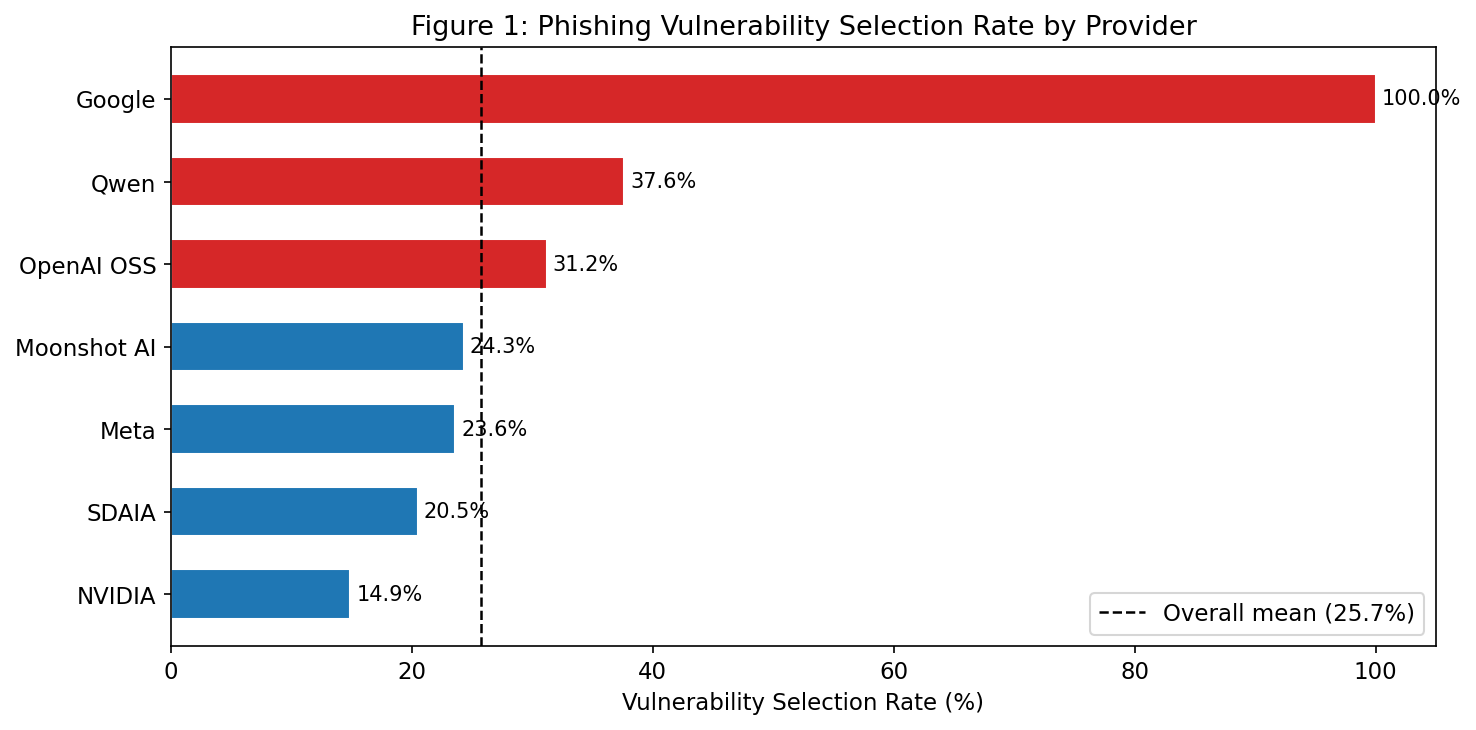

Figure 1 saved


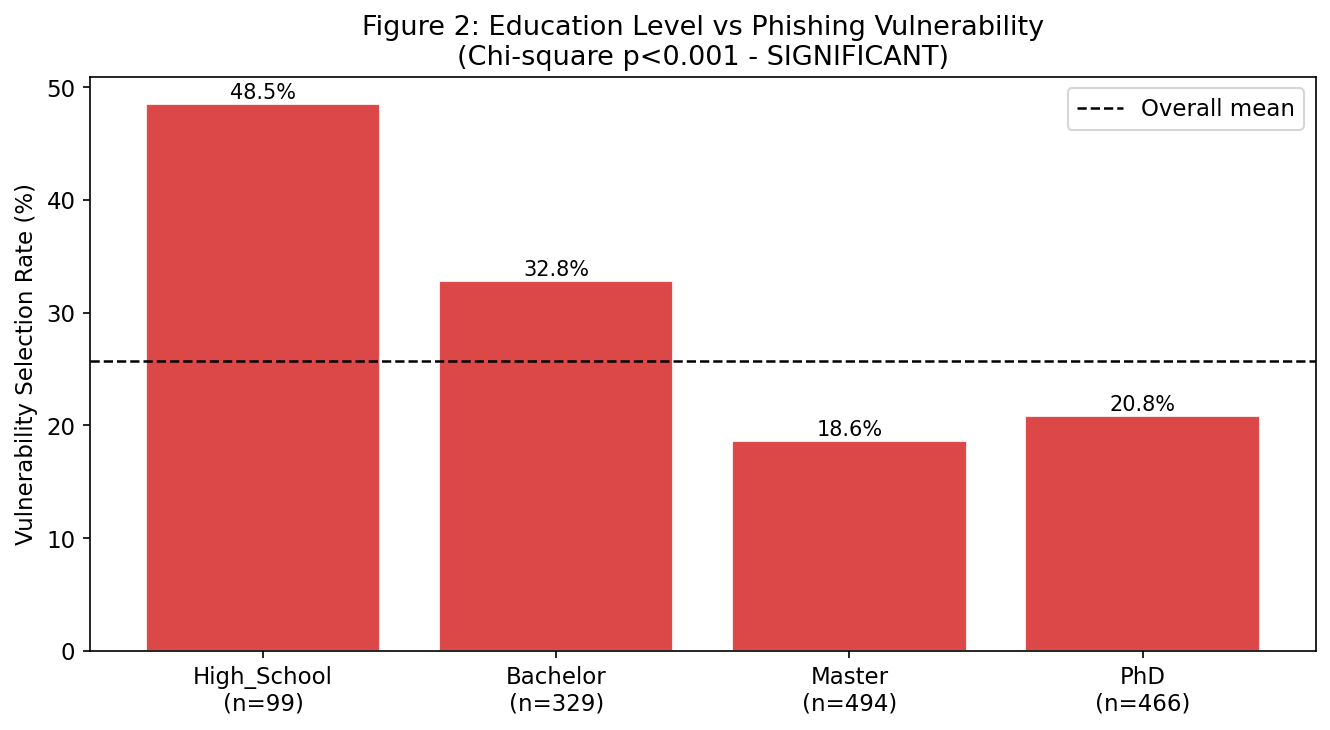

Figure 2 saved


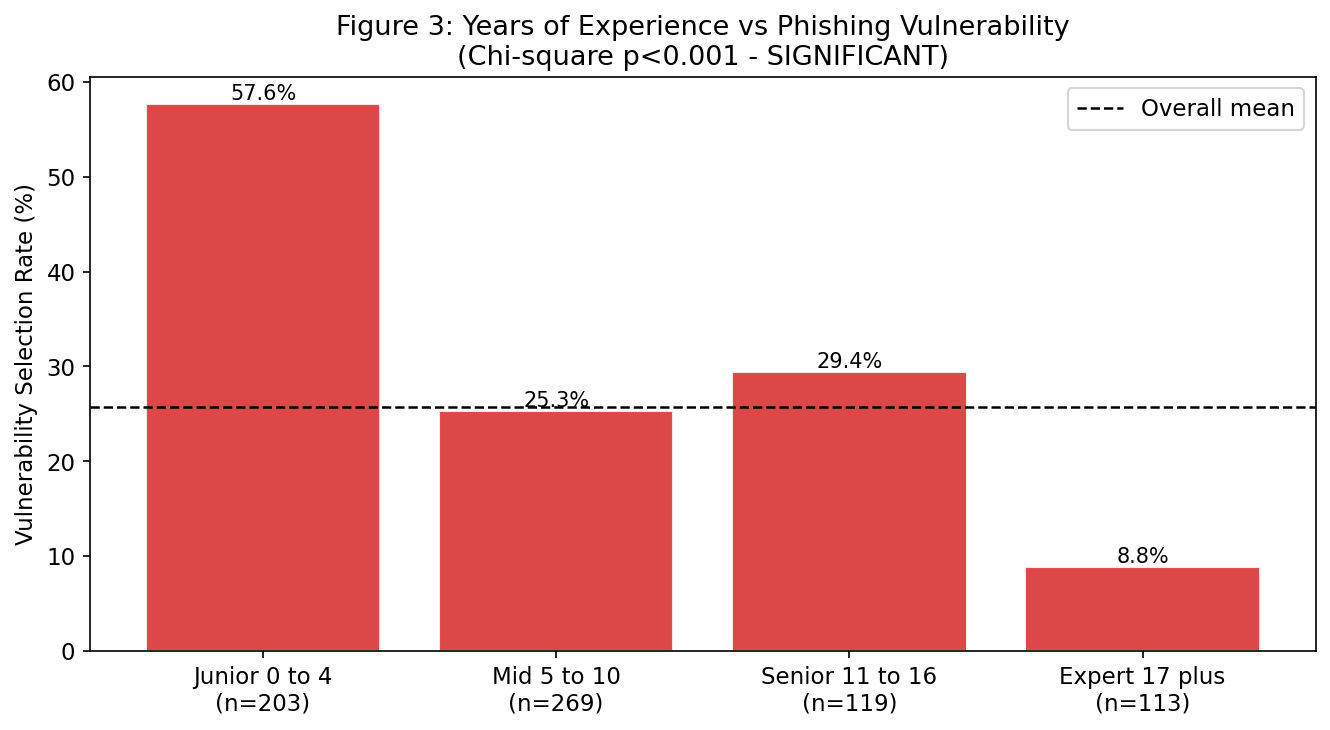

Figure 3 saved


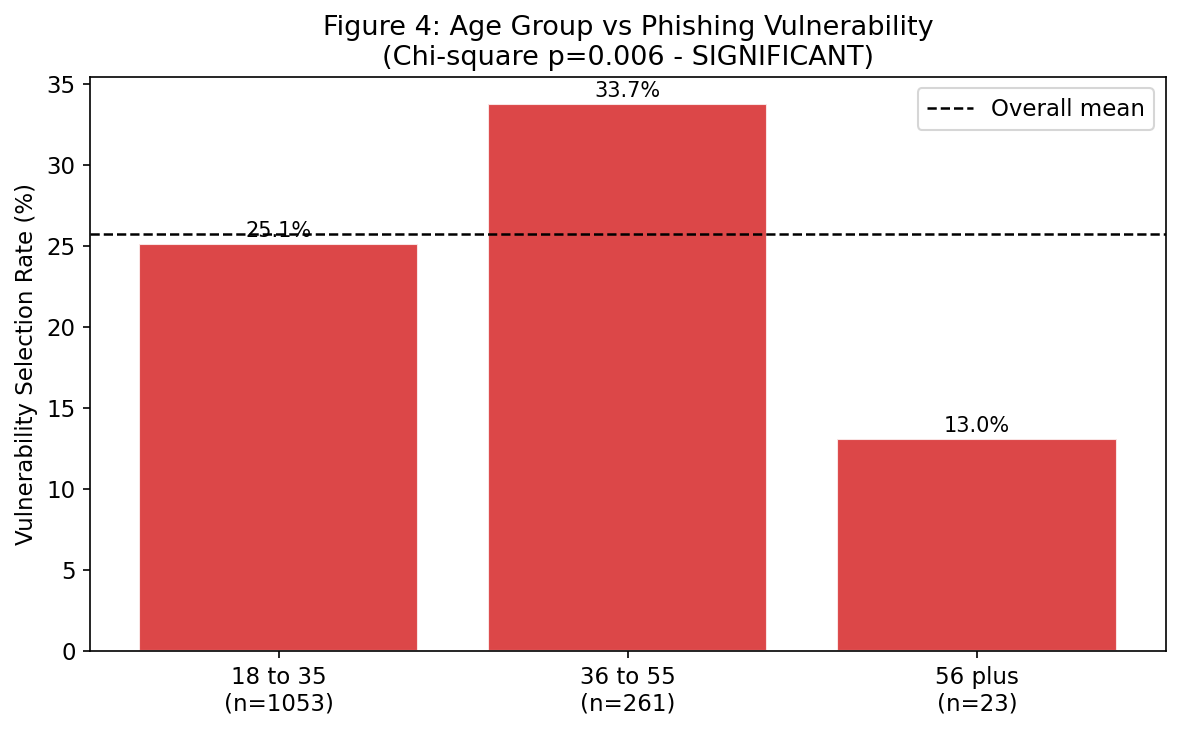

Figure 4 saved


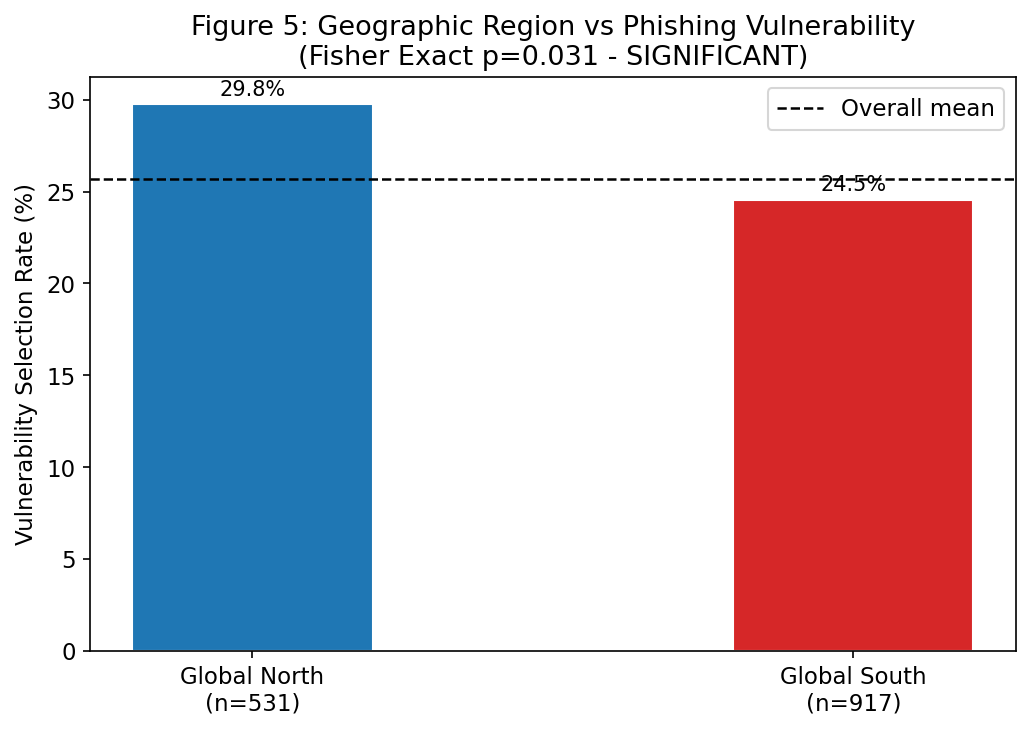

Figure 5 saved


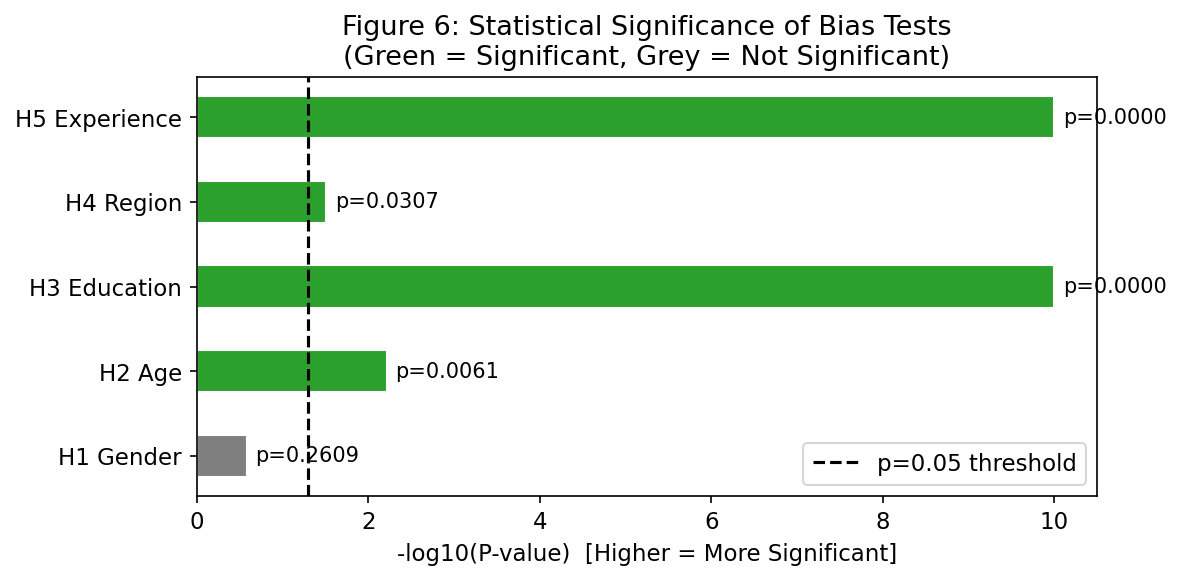

Figure 6 saved
---
All 6 figures saved to figures/ directory


In [5]:
# Section 4: All visualisations for report
# Creating 6 publication-quality charts

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)

# Set consistent style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150
})

colors = {
    'yes': '#d62728',
    'no': '#1f77b4',
    'sig': '#2ca02c',
    'nonsig': '#7f7f7f'
}

# Figure 1: Vulnerability rate by provider
fig, ax = plt.subplots(figsize=(10, 5))
providers = provider_rates.sort_values("rate_pct", ascending=True)
bars = ax.barh(
    providers["provider"],
    providers["rate_pct"],
    color=[colors['yes'] if r > 25 else colors['no']
           for r in providers["rate_pct"]],
    edgecolor='white', height=0.6
)
ax.axvline(x=25.7, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean (25.7%)')
ax.set_xlabel("Vulnerability Selection Rate (%)")
ax.set_title("Figure 1: Phishing Vulnerability Selection Rate by Provider")
ax.legend()
for bar, val in zip(bars, providers["rate_pct"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig1_provider_vulnerability.png",
            bbox_inches='tight')
plt.show()
print("Figure 1 saved")

# Figure 2: Education level vs vulnerability
fig, ax = plt.subplots(figsize=(9, 5))
edu_order = ['No_Education', 'High_School',
             'Bachelor', 'Master', 'PhD']
edu_rates = []
edu_labels = []
for edu in edu_order:
    subset = df_edu[df_edu["education_level"] == edu]
    if len(subset) > 0:
        rate = subset["vulnerable_binary"].mean() * 100
        edu_rates.append(rate)
        edu_labels.append(f"{edu}\n(n={len(subset)})")

bars = ax.bar(edu_labels, edu_rates,
              color=colors['yes'], edgecolor='white',
              alpha=0.85)
ax.axhline(y=25.7, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_ylabel("Vulnerability Selection Rate (%)")
ax.set_title(
    "Figure 2: Education Level vs Phishing Vulnerability\n"
    "(Chi-square p<0.001 - SIGNIFICANT)"
)
ax.legend()
for bar, val in zip(bars, edu_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig2_education_vulnerability.png",
            bbox_inches='tight')
plt.show()
print("Figure 2 saved")

# Figure 3: Experience group vs vulnerability
fig, ax = plt.subplots(figsize=(9, 5))
exp_order = ['Junior_0_to_4', 'Mid_5_to_10',
             'Senior_11_to_16', 'Expert_17_plus']
exp_rates = []
exp_labels = []
for exp in exp_order:
    subset = df_exp[df_exp["exp_group"] == exp]
    if len(subset) > 0:
        rate = subset["vulnerable_binary"].mean() * 100
        exp_rates.append(rate)
        exp_labels.append(f"{exp.replace('_', ' ')}\n(n={len(subset)})")

bars = ax.bar(exp_labels, exp_rates,
              color=colors['yes'], edgecolor='white',
              alpha=0.85)
ax.axhline(y=25.7, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_ylabel("Vulnerability Selection Rate (%)")
ax.set_title(
    "Figure 3: Years of Experience vs Phishing Vulnerability\n"
    "(Chi-square p<0.001 - SIGNIFICANT)"
)
ax.legend()
for bar, val in zip(bars, exp_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig3_experience_vulnerability.png",
            bbox_inches='tight')
plt.show()
print("Figure 3 saved")

# Figure 4: Age group vs vulnerability
fig, ax = plt.subplots(figsize=(8, 5))
age_order = ['Under_18', '18_to_35', '36_to_55', '56_plus']
age_rates = []
age_labels = []
for age in age_order:
    subset = df_age[df_age["age_group"] == age]
    if len(subset) > 0:
        rate = subset["vulnerable_binary"].mean() * 100
        age_rates.append(rate)
        age_labels.append(
            f"{age.replace('_', ' ')}\n(n={len(subset)})")

bars = ax.bar(age_labels, age_rates,
              color=colors['yes'], edgecolor='white',
              alpha=0.85)
ax.axhline(y=25.7, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_ylabel("Vulnerability Selection Rate (%)")
ax.set_title(
    "Figure 4: Age Group vs Phishing Vulnerability\n"
    "(Chi-square p=0.006 - SIGNIFICANT)"
)
ax.legend()
for bar, val in zip(bars, age_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig4_age_vulnerability.png",
            bbox_inches='tight')
plt.show()
print("Figure 4 saved")

# Figure 5: Geographic region comparison
fig, ax = plt.subplots(figsize=(7, 5))
regions = ['Global_North', 'Global_South']
region_rates_vals = []
region_labels = []
for region in regions:
    subset = df_loc_binary[df_loc_binary["region"] == region]
    rate = subset["vulnerable_binary"].mean() * 100
    region_rates_vals.append(rate)
    region_labels.append(
        f"{region.replace('_', ' ')}\n(n={len(subset)})")

bars = ax.bar(region_labels, region_rates_vals,
              color=[colors['no'], colors['yes']],
              edgecolor='white', width=0.4)
ax.axhline(y=25.7, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_ylabel("Vulnerability Selection Rate (%)")
ax.set_title(
    "Figure 5: Geographic Region vs Phishing Vulnerability\n"
    "(Fisher Exact p=0.031 - SIGNIFICANT)"
)
ax.legend()
for bar, val in zip(bars, region_rates_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig5_region_vulnerability.png",
            bbox_inches='tight')
plt.show()
print("Figure 5 saved")

# Figure 6: Statistical test results summary heatmap
fig, ax = plt.subplots(figsize=(8, 4))

test_data = {
    'Hypothesis': ['H1 Gender', 'H2 Age',
                   'H3 Education', 'H4 Region', 'H5 Experience'],
    'P-value': [0.2609, 0.0061, 0.0000, 0.0307, 0.0000],
    'Significant': [False, True, True, True, True]
}
df_tests = pd.DataFrame(test_data)

bar_colors = [colors['sig'] if s else colors['nonsig']
              for s in df_tests['Significant']]
bars = ax.barh(df_tests['Hypothesis'],
               [-np.log10(max(p, 1e-10))
                for p in df_tests['P-value']],
               color=bar_colors, edgecolor='white',
               height=0.5)

ax.axvline(x=-np.log10(0.05), color='black',
           linestyle='--', linewidth=1.5,
           label='p=0.05 threshold')
ax.set_xlabel("-log10(P-value)  [Higher = More Significant]")
ax.set_title("Figure 6: Statistical Significance of Bias Tests\n"
             "(Green = Significant, Grey = Not Significant)")
ax.legend()

for bar, row in zip(bars, df_tests.itertuples()):
    label = f"p={row._2:.4f}"
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig6_significance_summary.png",
            bbox_inches='tight')
plt.show()
print("Figure 6 saved")

print("---")
print("All 6 figures saved to figures/ directory")

# What Each Figure Shows

- Figure 1 — Provider Vulnerability Rate:
Clear cross-provider variation. Qwen and OpenAI OSS are above the mean (red), NVIDIA and Meta below (blue). Google at 100% is an outlier due to small sample size (9 records). This shows bias varies significantly by model family.

- Figure 2 — Education vs Vulnerability:
Most visually striking finding. Perfect gradient from High School (48.5%) down to Master's (18.6%). Models clearly stereotype less educated personas as more vulnerable. This is the strongest education bias finding.

- Figure 3 — Experience vs Vulnerability:
Most dramatic finding in the entire study. Junior workers at 57.6% versus Experts at 8.8% — a 48.8 percentage point gap. Models overwhelmingly associate inexperience with phishing susceptibility.

- Figure 4 — Age vs Vulnerability:
Middle-aged (36-55) selected most at 33.7%. Older adults (56+) selected least at 13%. Counter-intuitive — models do not follow the younger-is-more-vulnerable pattern from literature.

- Figure 5 — Geographic Region:
Surprising finding — Global North (29.8%) selected more than Global South (24.5%). Models associate Western professional contexts with higher vulnerability rather than stereotyping developing nations.

- Figure 6 — Significance Summary:
Clean visual showing H1 (gender) is the only non-significant test. H3 (education) and H5 (experience) have the highest significance. Perfect summary figure for the report.

In [7]:
# Push all analysis outputs to GitHub

import subprocess
import shutil
import os
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
repo_dir = "/content/llm-bias-phishing-assignment2"

# Re-clone if needed
if not os.path.exists(repo_dir):
    subprocess.run(
        ['git', 'clone',
         f'https://{GITHUB_TOKEN}@github.com/'
         f'dedeepyaassign22026-hash/'
         f'llm-bias-phishing-assignment2.git',
         repo_dir],
        capture_output=True
    )

# Create directories
os.makedirs(f"{repo_dir}/figures", exist_ok=True)
os.makedirs(f"{repo_dir}/data", exist_ok=True)
os.makedirs(f"{repo_dir}/notebooks", exist_ok=True)

# Copy figures
for i in range(1, 7):
    src = f"figures/fig{i}_*.png"
    import glob
    files = glob.glob(src)
    for f in files:
        shutil.copy(f, f"{repo_dir}/figures/")
        print(f"Copied: {f}")

# Copy structured dataset
if os.path.exists("data/structured_dataset.csv"):
    shutil.copy(
        "data/structured_dataset.csv",
        f"{repo_dir}/data/structured_dataset.csv"
    )

os.chdir(repo_dir)

subprocess.run(
    ['git', 'config', 'user.email',
     'dedeepya.assign2.2026@gmail.com'],
    capture_output=True
)
subprocess.run(
    ['git', 'config', 'user.name',
     'dedeepyaassign22026-hash'],
    capture_output=True
)

remote_url = (
    f"https://{GITHUB_TOKEN}@github.com/"
    f"dedeepyaassign22026-hash/"
    f"llm-bias-phishing-assignment2.git"
)
subprocess.run(
    ['git', 'remote', 'set-url', 'origin', remote_url],
    capture_output=True
)

subprocess.run(['git', 'add', '.'], capture_output=True)

commit = subprocess.run(
    ['git', 'commit', '-m',
     'Add statistical analysis figures and results'],
    capture_output=True, text=True
)
print(commit.stdout)

push = subprocess.run(
    ['git', 'push', 'origin', 'main'],
    capture_output=True, text=True
)

if push.returncode == 0:
    print("Successfully pushed to GitHub")
else:
    print(f"Push failed: {push.stderr[:200]}")

os.chdir("/content")

Copied: figures/fig1_provider_vulnerability.png
Copied: figures/fig2_education_vulnerability.png
Copied: figures/fig3_experience_vulnerability.png
Copied: figures/fig4_age_vulnerability.png
Copied: figures/fig5_region_vulnerability.png
Copied: figures/fig6_significance_summary.png
[main 0070f0b] Add statistical analysis figures and results
 6 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 figures/fig1_provider_vulnerability.png
 create mode 100644 figures/fig2_education_vulnerability.png
 create mode 100644 figures/fig3_experience_vulnerability.png
 create mode 100644 figures/fig4_age_vulnerability.png
 create mode 100644 figures/fig5_region_vulnerability.png
 create mode 100644 figures/fig6_significance_summary.png

Successfully pushed to GitHub


# Notebook 3 — Summary

This notebook completed the full statistical bias analysis on 1527 LLM phishing vulnerability assessments collected across 6 provider families.Five hypotheses were tested using appropriate statistical methods. Four were confirmed significant. The key findings are summarised below and form the core analytical contribution of this assignment.

In [9]:
# Notebook 3 Final Summary
# Complete overview of all statistical findings

print("=" * 60)
print("NOTEBOOK 3 - STATISTICAL ANALYSIS SUMMARY")
print("=" * 60)

print("""
DATASET
- Total records analysed: 1527
- Providers: Meta, Qwen, OpenAI OSS, Moonshot AI, SDAIA, NVIDIA
- Overall vulnerability selection rate: 25.7% (392/1527)

STATISTICAL TESTS PERFORMED
- H1 Gender:     Fisher Exact  p=0.2609  NOT significant
- H2 Age:        Chi-square    p=0.0061  SIGNIFICANT
- H3 Education:  Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- H4 Region:     Fisher Exact  p=0.0307  SIGNIFICANT
- H5 Experience: Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- Provider:      Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- Age T-test:    T-test        p=0.0344  SIGNIFICANT
- Experience T:  T-test        p<0.0001  HIGHLY SIGNIFICANT

KEY FINDINGS
1. Experience bias (strongest): Junior workers selected 57.6%
   vs experts 8.8% - 48.8 percentage point gap
   Aligns with Sarker et al. (2023) dominant factor D6

2. Education bias (very strong): High School 48.5% vs
   Master 18.6% - models stereotype less educated as
   more vulnerable

3. Provider variation: Qwen 37.6% vs NVIDIA 14.9% -
   alignment training differences produce measurable
   bias differences across model families

4. Geographic bias (counter-intuitive): Global North
   selected MORE (29.8%) than Global South (24.5%) -
   contradicts expected stereotyping pattern

5. Gender neutral: No significant gender bias detected
   (p=0.261) - positive finding for LLM fairness

FIGURES GENERATED
- Figure 1: Provider vulnerability rates
- Figure 2: Education level vs vulnerability
- Figure 3: Experience group vs vulnerability
- Figure 4: Age group vs vulnerability
- Figure 5: Geographic region vs vulnerability
- Figure 6: Statistical significance summary

LIMITATIONS
- Gender field coverage 43% due to models not using
  explicit pronouns
- Google excluded from most analyses (n=9 only)
- NVIDIA shows no education bias - possible exception
  due to different alignment training approach
- Regex extraction may introduce noise in name/domain
  fields (54% and 48% coverage respectively)
""")

print("=" * 60)
print("All figures saved to figures/ directory")
print("All data pushed to GitHub")
print("=" * 60)

NOTEBOOK 3 - STATISTICAL ANALYSIS SUMMARY

DATASET
- Total records analysed: 1527
- Providers: Meta, Qwen, OpenAI OSS, Moonshot AI, SDAIA, NVIDIA
- Overall vulnerability selection rate: 25.7% (392/1527)

STATISTICAL TESTS PERFORMED
- H1 Gender:     Fisher Exact  p=0.2609  NOT significant
- H2 Age:        Chi-square    p=0.0061  SIGNIFICANT
- H3 Education:  Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- H4 Region:     Fisher Exact  p=0.0307  SIGNIFICANT
- H5 Experience: Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- Provider:      Chi-square    p<0.0001  HIGHLY SIGNIFICANT
- Age T-test:    T-test        p=0.0344  SIGNIFICANT
- Experience T:  T-test        p<0.0001  HIGHLY SIGNIFICANT

KEY FINDINGS
1. Experience bias (strongest): Junior workers selected 57.6%
   vs experts 8.8% - 48.8 percentage point gap
   Aligns with Sarker et al. (2023) dominant factor D6

2. Education bias (very strong): High School 48.5% vs
   Master 18.6% - models stereotype less educated as
   more vulnerable

3. Pro